In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
x = np.array([2,4,6,8,10])
y = np.array([40, 45, 50, 73, 80])

x_mean = np.mean(x)
y_mean = np.mean(y)

print(f'{x_mean}, {y_mean}')

# 분자
numerator = np.sum((x-x_mean) * (y-y_mean))
# 분모
denominator = np.sum((x - x_mean)**2)

w = numerator / denominator
b = y_mean - w * x_mean

print(f"수학 공식으로 찾은 W(기울기): {w}")
print(f"수학 공식으로 찾은 b(절편): {b}")

x_new = 7
y_pred = w * x_new + b
print(f"진동이 {x_new}일 때 예측되는 온도: {y_pred}도")

6.0, 57.6
수학 공식으로 찾은 W(기울기): 5.4
수학 공식으로 찾은 b(절편): 25.199999999999996
진동이 7일 때 예측되는 온도: 63.0도


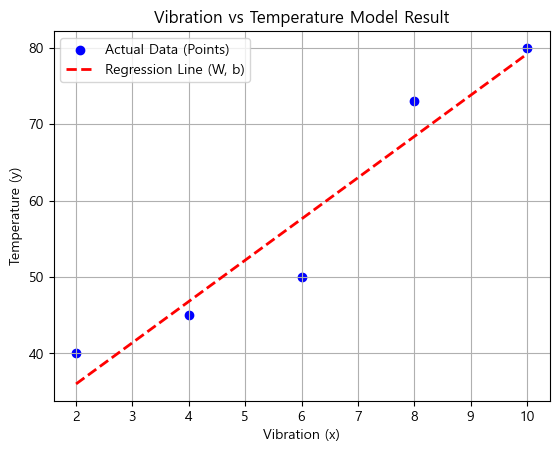

In [10]:
plt.scatter(x, y, color='blue', label='Actual Data (Points)')
y_pred = w * x + b
plt.plot(x, y_pred, color='red', linestyle='--', linewidth=2, label='Regression Line (W, b)')

plt.xlabel('Vibration (x)') # x축 이름
plt.ylabel('Temperature (y)') # y축 이름
plt.title('Vibration vs Temperature Model Result') # 그래프 제목
plt.legend() # 범례 표시 (color='blue', label='...' 했던 것들)
plt.grid(True) # 그리드(격자) 표시

plt.show()

--- 학습 결과 ---
우리가 미리 정한 실제 정답: [5.  3.  1.5 0.8]
모델이 공식을 풀어 찾아낸 정답(theta_best): [4.73501456 3.13900206 1.4211189  1.08520288]
 -> 절편 b=4.74, w1=3.14, w2=1.42, w3=1.09


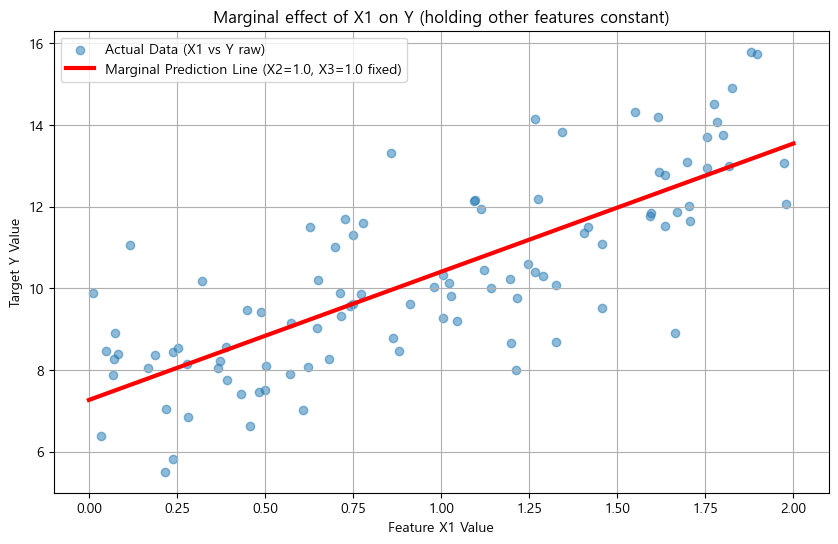

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 가상의 다중 데이터 생성 (변수 3개)
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정

n_samples = 100 # 데이터 개수 100개
# 우리가 미리 정해둔 완벽한 정답 (theta): [intercept=5, w1=3, w2=1.5, w3=0.8]
true_theta = np.array([5, 3, 1.5, 0.8])

# 독립 변수 x1, x2, x3 생성 (0~2 사이 랜덤 숫자)
x_data = 2 * np.random.rand(n_samples, 3)

# 종속 변수 y 생성 (정답 공식 + 약간의 노이즈)
# y = 5 + 3*x1 + 1.5*x2 + 0.8*x3 + noise
noise = np.random.randn(n_samples) # 평균 0, 표준편차 1인 노이즈
y = true_theta[0] + np.dot(x_data, true_theta[1:]) + noise


# 2. 💡 [실습] 정규 방정식 공식 그대로 theta 계산하기
# theta = (X^T * X)^-1 * X^T * y

# (1) 디자인 행렬 X 만들기: 맨 왼쪽에 1로 가득 찬 기둥 추가 (절편 theta0용)
X_design = np.c_[np.ones((n_samples, 1)), x_data]

# (2) 공식 구현 (numpy의 선형대수 함수 이용)
# np.linalg.inv(): 역행렬 계산 / .T: 전치 행렬 / @: 행렬 곱셈
Xt_X = X_design.T @ X_design # X^T * X
Xt_X_inv = np.linalg.inv(Xt_X) # (X^T * X)^-1
Xt_y = X_design.T @ y # X^T * y

# 최종 세타 계산
theta_best = Xt_X_inv @ Xt_y

print("--- 학습 결과 ---")
print(f"우리가 미리 정한 실제 정답: {true_theta}")
print(f"모델이 공식을 풀어 찾아낸 정답(theta_best): {theta_best}")
print(f" -> 절편 b={theta_best[0]:.2f}, w1={theta_best[1]:.2f}, w2={theta_best[2]:.2f}, w3={theta_best[3]:.2f}")


# 3. 💡 [실습] 그래프 시각화 (4차원이 불가능하므로 '단면' 그래프)
# 전략: X1 변수만 변화시키고, X2와 X3는 평균값으로 고정해둔 뒤 모델이 예측하는 '선'을 그리자.

# (1) 그래프 그릴 X1의 범위 설정
x1_range = np.linspace(0, 2, 100)

# (2) X2, X3의 평균값 계산 (고정값)
x2_mean = x_data[:, 1].mean()
x3_mean = x_data[:, 2].mean()

# (3) 예측을 위한 가짜 데이터 행렬 만들기
# 형태: [1, x1_range값들, x2평균, x3평균]
X_plot = np.c_[np.ones((100, 1)), x1_range, np.full((100, 1), x2_mean), np.full((100, 1), x3_mean)]

# (4) 학습된 theta를 이용해 예측값 계산 (y = X_plot * theta_best)
y_plot_pred = X_plot @ theta_best

# (5) 그래프 그리기
plt.figure(figsize=(10, 6))

# 실제 데이터 포인트 (Note: 이 점들은 X2, X3 노이즈 때문에 선 주변에 완벽하게 모여있진 않음)
plt.scatter(x_data[:, 0], y, alpha=0.5, label='Actual Data (X1 vs Y raw)')

# 단면 예측선 그리기 (X2, X3 고정된 상태)
plt.plot(x1_range, y_plot_pred, color='red', linewidth=3, label=f'Marginal Prediction Line (X2={x2_mean:.1f}, X3={x3_mean:.1f} fixed)')

plt.xlabel('Feature X1 Value')
plt.ylabel('Target Y Value')
plt.title('Marginal effect of X1 on Y (holding other features constant)')
plt.legend()
plt.grid(True)
plt.show()

찾아낸 방정식: y = 2.82 + 1.93*x1 + 1.64*x2


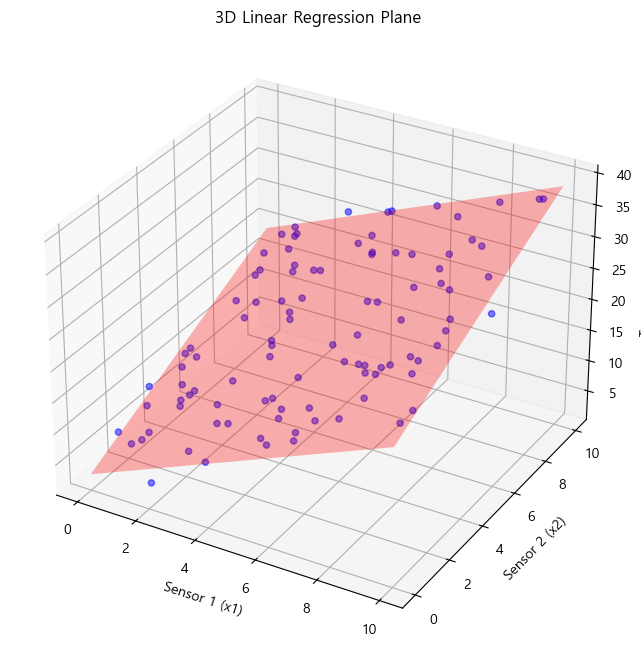

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # 3D 그래프를 그리기 위한 라이브러리

# 1. 가상의 데이터 생성 (독립 변수 2개: x1, x2)
np.random.seed(42)
n_samples = 100

# x1, x2 데이터 생성 (0~10 사이의 값)
x1 = 10 * np.random.rand(n_samples)
x2 = 10 * np.random.rand(n_samples)

# 완벽한 정답 세팅: y = 3 + 2*x1 + 1.5*x2 + 노이즈
true_theta = np.array([3, 2, 1.5])
y = true_theta[0] + true_theta[1]*x1 + true_theta[2]*x2 + np.random.randn(n_samples)*2

# 2. 정규 방정식으로 최적의 theta 구하기 (아까 배운 그 공식!)
# X 행렬 만들기 (맨 앞에 1 추가)
X = np.c_[np.ones(n_samples), x1, x2]

# theta = (X^T * X)^-1 * X^T * y
theta_best = np.linalg.inv(X.T @ X) @ X.T @ y

print(f"찾아낸 방정식: y = {theta_best[0]:.2f} + {theta_best[1]:.2f}*x1 + {theta_best[2]:.2f}*x2")

# 3. 3D 그래프 그리기 세팅
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# (1) 실제 데이터 점 찍기 (파란색 점)
ax.scatter(x1, x2, y, c='blue', marker='o', alpha=0.5, label='Actual Data')

# (2) 모델이 예측한 '평면' 그리기
# 평면을 그리기 위해 x1과 x2의 격자(Grid) 판넬을 만들어줌
x1_mesh, x2_mesh = np.meshgrid(np.linspace(0, 10, 10), np.linspace(0, 10, 10))
# 각 격자점에서의 예측 y값 계산 (y = b + w1*x1 + w2*x2)
y_mesh = theta_best[0] + theta_best[1]*x1_mesh + theta_best[2]*x2_mesh

# 빨간색 반투명 평면 그리기
ax.plot_surface(x1_mesh, x2_mesh, y_mesh, color='red', alpha=0.3)

# 축 이름 설정
ax.set_xlabel('Sensor 1 (x1)')
ax.set_ylabel('Sensor 2 (x2)')
ax.set_zlabel('Temperature (y)')
ax.set_title('3D Linear Regression Plane')

plt.show()